# MSA 2026 Phase 2 - Part 1

In [70]:
# !pip install -r requirements.txt

In [71]:
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Find all variables and understand them

In [72]:
# Load X store sales data & preview the first 10 rows
xsales_data = pd.read_csv('datasets/X store sales/store_sales.csv', encoding='latin1')
xsales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [73]:
# check data types and missing values
xsales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   str    
 2   Order Date     2121 non-null   str    
 3   Ship Date      2121 non-null   str    
 4   Ship Mode      2121 non-null   str    
 5   Customer ID    2121 non-null   str    
 6   Customer Name  2121 non-null   str    
 7   Segment        2121 non-null   str    
 8   Country        2121 non-null   str    
 9   City           2121 non-null   str    
 10  State          2121 non-null   str    
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   str    
 13  Product ID     2121 non-null   str    
 14  Category       2121 non-null   str    
 15  Sub-Category   2121 non-null   str    
 16  Product Name   2121 non-null   str    
 17  Sales          2121 non-null   float64
 18  Quantity       2121

In [74]:
# Check duplicates
duplicates = xsales_data.duplicated().sum()
print(f'The number of duplicate records is: {duplicates}')

The number of duplicate records is: 0


### 1.1 View time range of the data

In [75]:
xsales_data['Order Date'] = pd.to_datetime(xsales_data['Order Date'])
print('Data covers from {} to {}'.format(xsales_data['Order Date'].min(), xsales_data['Order Date'].max()))

Data covers from 2014-01-06 00:00:00 to 2017-12-30 00:00:00


### 1.2 Statistical measures of key numeric columns

In [76]:
# key statistical measures of the numeric columns:sales/quantity/discount/profit
xsales_data[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000
mean,349.834887,3.785007,0.173923,8.699327
std,503.179145,2.251620,0.181547,136.049246
min,1.892000,1.000000,0.000000,-1862.312400
25%,47.040000,2.000000,0.000000,-12.849000
50%,182.220000,3.000000,0.200000,7.774800
75%,435.168000,5.000000,0.300000,33.726600
max,4416.174000,14.000000,0.700000,1013.127000


### 1.3 Visualisation to check data distribution

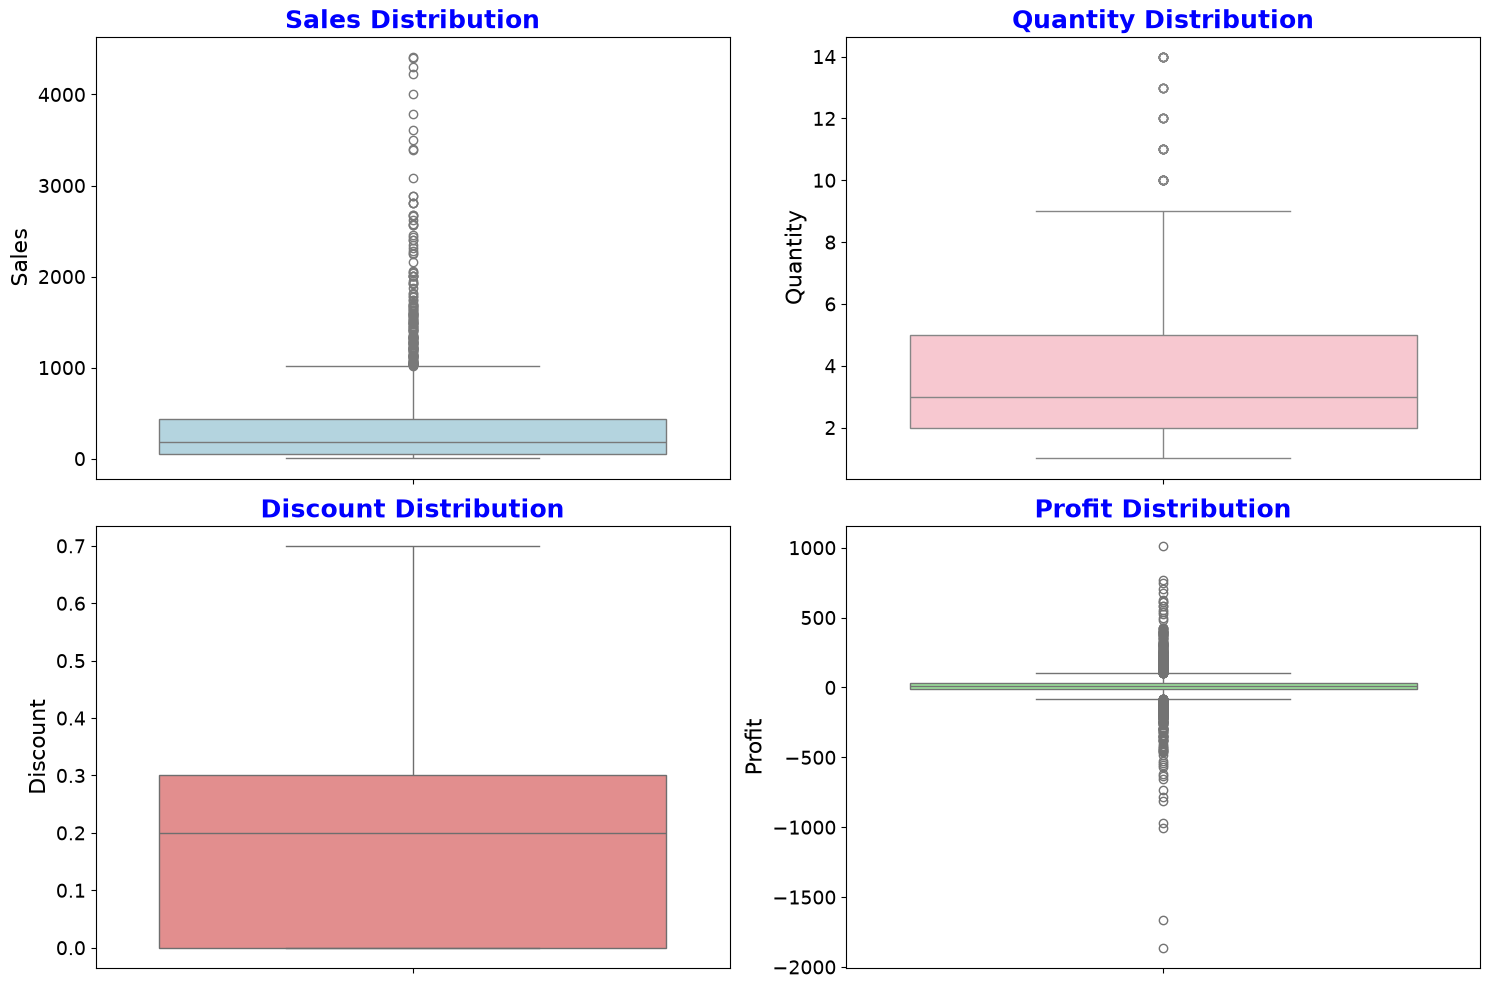

In [77]:
# Check distribution of sales, quantity, discount and profit using boxplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.boxplot(data=xsales_data['Sales'], ax=axes[0, 0], color='lightblue')
sns.boxplot(data=xsales_data['Quantity'], ax=axes[0, 1], color='pink')
sns.boxplot(data=xsales_data['Discount'], ax=axes[1, 0], color='lightcoral')
sns.boxplot(data=xsales_data['Profit'], ax=axes[1, 1], color='lightgreen')

# Set title and label format for all subplots
# Titles for each subplot
titles = [
    "Sales Distribution",
    "Quantity Distribution",
    "Discount Distribution",
    "Profit Distribution"
]

# Style settings
title_style = {
    'fontsize': 18,
    'fontweight': 'bold',
    'color': 'blue'
}

label_size = 16
tick_size = 14

# Apply to all subplots
for ax, title in zip(axes.flat, titles):

    # Title
    ax.set_title(title, **title_style)

    # Axis labels
    ax.set_xlabel(ax.get_xlabel(), fontsize=label_size)
    ax.set_ylabel(ax.get_ylabel(), fontsize=label_size)

    # Tick labels
    ax.tick_params(axis='both', labelsize=tick_size)

# set all x and y labels with font size 16; set all x ticks with font size 12
plt.tight_layout()
plt.show()


In [78]:
# Check outliers in sales using quantiles
sales_q1 = xsales_data['Sales'].quantile(0.25)
sales_q3 = xsales_data['Sales'].quantile(0.75)
sales_iqr = sales_q3 - sales_q1
sales_lower_bound = sales_q1 - 1.5 * sales_iqr
sales_upper_bound = sales_q3 + 1.5 * sales_iqr
outliers_sales = xsales_data[(xsales_data['Sales'] < sales_lower_bound) | (xsales_data['Sales'] > sales_upper_bound)]
print(f'Number of outliers in Sales: {outliers_sales.shape[0]}')
# Show outlier records in decending order of sales amount
outliers_sales_sorted = outliers_sales.sort_values(by='Sales', ascending=False)
outliers_sales_sorted.head()

Number of outliers in Sales: 164


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1517,7244,CA-2017-118892,2017-08-17,8/22/2017,Second Class,TP-21415,Tom Prescott,Consumer,United States,Philadelphia,...,19134,East,FUR-CH-10002024,Furniture,Chairs,HON 5400 Series Task Chairs for Big and Tall,4416.174,9,0.3,-630.8820
2063,9742,CA-2015-117086,2015-11-08,11/12/2015,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,...,5408,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",4404.900,5,0.0,1013.1270
2044,9640,CA-2015-116638,2015-01-28,1/31/2015,Second Class,JH-15985,Joseph Holt,Consumer,United States,Concord,...,28027,South,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124
1232,5918,US-2015-126977,2015-09-17,9/23/2015,Standard Class,PF-19120,Peter Fuller,Consumer,United States,New York City,...,10035,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",4228.704,6,0.2,158.5764
1365,6536,CA-2014-128209,2014-11-17,11/22/2014,Standard Class,GT-14710,Greg Tran,Consumer,United States,Buffalo,...,14215,East,FUR-BO-10002213,Furniture,Bookcases,DMI Eclipse Executive Suite Bookcases,4007.840,10,0.2,-50.0980


In [79]:
# Check outliers in profit using quantiles
profit_q1 = xsales_data['Profit'].quantile(0.25)
profit_q3 = xsales_data['Profit'].quantile(0.75)
profit_iqr = profit_q3 - profit_q1
profit_lower_bound = profit_q1 - 1.5 * profit_iqr
profit_upper_bound = profit_q3 + 1.5 * profit_iqr
outliers_profit = xsales_data[(xsales_data['Profit'] < profit_lower_bound) | (xsales_data['Profit'] > profit_upper_bound)]
print(f'Number of outliers in Profit: {outliers_profit.shape[0]}')
# Show outlier records in decending order of profit amount
outliers_profit_sorted = outliers_profit.sort_values(by='Profit', ascending=False)
outliers_profit_sorted.head()

Number of outliers in Profit: 407


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2063,9742,CA-2015-117086,2015-11-08,11/12/2015,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,...,5408,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",4404.90,5,0.0,1013.1270
1452,6885,CA-2015-120677,2015-05-31,6/4/2015,Standard Class,BD-11320,Bill Donatelli,Consumer,United States,Minneapolis,...,55407,Central,FUR-CH-10002320,Furniture,Chairs,Hon Pagoda Stacking Chairs,2567.84,8,0.0,770.3520
1577,7475,CA-2014-167199,2014-01-06,1/10/2014,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2573.82,9,0.0,746.4078
1070,5171,CA-2016-122903,2016-05-27,5/29/2016,Second Class,LA-16780,Laura Armstrong,Corporate,United States,Detroit,...,48205,Central,FUR-CH-10002024,Furniture,Chairs,HON 5400 Series Task Chairs for Big and Tall,3504.90,5,0.0,700.9800
366,1792,CA-2014-120474,2014-12-01,12/3/2014,First Class,RP-19390,Resi Plking,Consumer,United States,Madison,...,53711,Central,FUR-CH-10001854,Furniture,Chairs,Office Star - Professional Matrix Back Chair w...,2807.84,8,0.0,673.8816


* Decided to keep outliers as these could reflect real-world business cases

## 2. Clean data

### 2.1 Standardise data

In [80]:
# Standardize the numeric columns to deal with outliers and different scales
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xsales_data_scaled = xsales_data.copy()
xsales_data_scaled[['Sales', 'Quantity', 'Discount', 'Profit']] = scaler.fit_transform(xsales_data_scaled[['Sales', 'Quantity', 'Discount', 'Profit']])
xsales_data_scaled.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,-0.174681,-0.792953,-0.958228,0.244192
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",0.759561,-0.348723,-0.958228,1.550412
2,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1.208090,0.539736,1.521050,-2.880006
3,6,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,-0.598288,1.428194,-0.958228,0.040216
4,11,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,2.696195,2.316653,0.143673,0.563237


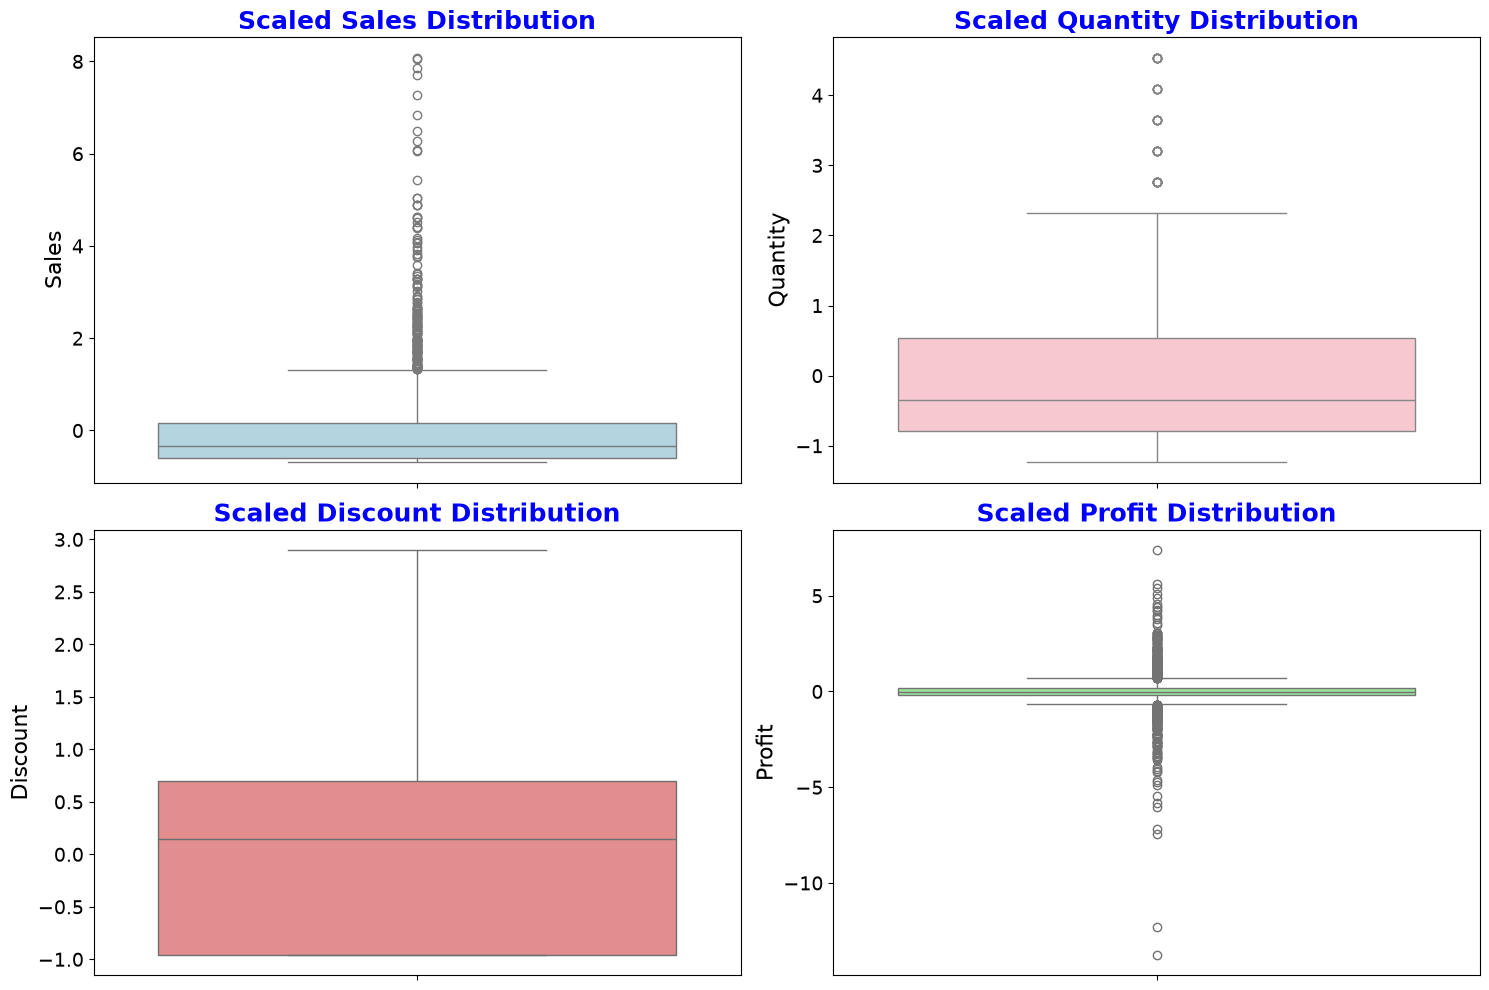

In [81]:
# Check the distribution of scaled data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.boxplot(data=xsales_data_scaled['Sales'], ax=axes[0, 0], color='lightblue')
sns.boxplot(data=xsales_data_scaled['Quantity'], ax=axes[0, 1], color='pink')
sns.boxplot(data=xsales_data_scaled['Discount'], ax=axes[1, 0], color='lightcoral')
sns.boxplot(data=xsales_data_scaled['Profit'], ax=axes[1, 1], color='lightgreen')
# Titles for each subplot
titles = [
    "Scaled Sales Distribution",
    "Scaled Quantity Distribution",
    "Scaled Discount Distribution",
    "Scaled Profit Distribution"
]
# Style settings
title_style = {
    'fontsize': 18,
    'fontweight': 'bold',
    'color': 'blue'
}
label_size = 16
tick_size = 14
# Apply to all subplots
for ax, title in zip(axes.flat, titles):
    # Title
    ax.set_title(title, **title_style)
    # Axis labels
    ax.set_xlabel(ax.get_xlabel(), fontsize=label_size)
    ax.set_ylabel(ax.get_ylabel(), fontsize=label_size)
    # Tick labels
    ax.tick_params(axis='both', labelsize=tick_size)
plt.tight_layout()
plt.show()

### 2.2 Check categorical balance

In [82]:
# Check sample balance by year
# extract year from order date and create a new column for it
xsales_data_scaled['Year'] = xsales_data_scaled['Order Date'].dt.year
# group by year and get the count of samples for each year
yearly_counts = xsales_data_scaled.groupby('Year').size()
yearly_counts

Year
2014    421
2015    452
2016    562
2017    686
dtype: int64

In [83]:
# Check sample balance by Sub-Category
subcategory_counts = xsales_data_scaled['Sub-Category'].value_counts()
subcategory_counts

Sub-Category
Furnishings    957
Chairs         617
Tables         319
Bookcases      228
Name: count, dtype: int64

In [84]:
# Check sample balance by region
region_counts = xsales_data_scaled['Region'].value_counts()
region_counts

Region
West       707
East       601
Central    481
South      332
Name: count, dtype: int64

In [85]:
# Check sample balance by consumer segment
consumer_segment_counts = xsales_data_scaled['Segment'].value_counts()
consumer_segment_counts

Segment
Consumer       1113
Corporate       646
Home Office     362
Name: count, dtype: int64

### 2.3 Feature engineering

In [86]:
# Add month/quarter columns for potential seasonality analysis
xsales_data_scaled['Month'] = xsales_data_scaled['Order Date'].dt.month
xsales_data_scaled['Quarter'] = xsales_data_scaled['Order Date'].dt.quarter
xsales_data_scaled.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,-0.174681,-0.792953,-0.958228,0.244192,2016,11,4
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",0.759561,-0.348723,-0.958228,1.550412,2016,11,4
2,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1.208090,0.539736,1.521050,-2.880006,2015,10,4
3,6,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,-0.598288,1.428194,-0.958228,0.040216,2014,6,2
4,11,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furniture,Tables,Chromcraft Rectangular Conference Tables,2.696195,2.316653,0.143673,0.563237,2014,6,2


### 2.4 Feature selection

In [87]:
# Remove identifier columns that do not provide predictive information.
# These columns uniquely identify records and may lead to overfitting
# if included in machine learning models.
id_columns = [
    'Row ID',
    'Order ID',
    'Customer ID',
    'Customer Name',
    'Product ID'
]
xsales_data_model = xsales_data_scaled.drop(columns=id_columns)
xsales_data_model.head()

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter
0,2016-11-08,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,-0.174681,-0.792953,-0.958228,0.244192,2016,11,4
1,2016-11-08,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",0.759561,-0.348723,-0.958228,1.550412,2016,11,4
2,2015-10-11,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1.208090,0.539736,1.521050,-2.880006,2015,10,4
3,2014-06-09,6/14/2014,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,-0.598288,1.428194,-0.958228,0.040216,2014,6,2
4,2014-06-09,6/14/2014,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Tables,Chromcraft Rectangular Conference Tables,2.696195,2.316653,0.143673,0.563237,2014,6,2


## 3. Visualise data

### 3.1 Yearly stats & visualisation

In [88]:
# group by year and get statistical measures of sales, quantity, discount and profit for each year
yearly_stats = xsales_data_scaled.groupby('Year')[['Sales', 'Quantity', 'Discount', 'Profit']].describe()
yearly_stats

Sales                                                              \
      count      mean       std       min       25%       50%       75%   
Year                                                                      
2014  421.0  0.046803  1.044235 -0.688495 -0.592165 -0.334681  0.323069   
2015  452.0  0.054502  1.153922 -0.689529 -0.587605 -0.313968  0.127858   
2016  562.0  0.008115  0.948300 -0.690785 -0.601727 -0.325557  0.207086   
2017  686.0 -0.071282  0.897863 -0.691652 -0.612004 -0.354921  0.063827   

               Quantity            ...  Discount           Profit            \
           max    count      mean  ...       75%       max  count      mean   
Year                               ...                                        
2014  7.271501    421.0  0.031140  ...  0.694624  2.898426  421.0  0.031352   
2015  8.060790    452.0  0.063073  ...  0.143673  2.898426  452.0 -0.014914   
2016  6.271741    562.0  0.052032  ...  0.694624  2.898426  562.0  0.027092   
2017  8.083201    686.0 -0.103296  ...  0.143673  2.898426  686.0 -0.031609   

                                                                   
           std        min       25%       50%       75%       max  
Year                                                               
2014  0.887080  -5.464205 -0.168569 -0.007373  0.156775  5.423642  
2015  1.308331 -13.755702 -0.154379  0.010857  0.236447  7.384565  
2016  0.895030  -6.052049 -0.152626 -0.003273  0.187914  5.089656  
2017  0.910193  -7.436436 -0.165067 -0.013430  0.145059  4.418680  

[4 rows x 32 columns]

In [92]:
# Examine yearly-quarterly trend of sales, quantity and profit using bar chart

# Create Year and Quarter columns
xsales_data['Year'] = xsales_data['Order Date'].dt.year
xsales_data['Quarter'] = xsales_data['Order Date'].dt.quarter

# Calculate quarterly average for sales, quantity and profit
quarterly_avg_by_yr = (
    xsales_data
    .groupby(['Year', 'Quarter'])[['Sales', 'Quantity', 'Profit']]
    .mean()
    .reset_index()
)

# Create a Year-Quarter label for plotting
quarterly_avg_by_yr['Year_Quarter'] = (
    quarterly_avg_by_yr['Year'].astype(str) + ' Q' + quarterly_avg_by_yr['Quarter'].astype(str)
)

quarterly_avg_by_yr.head()

,Year,Quarter,Sales,Quantity,Profit,Year_Quarter
0,2014,1,377.602317,3.733333,-3.374947,2014 Q1
1,2014,2,350.796870,3.750000,10.010223,2014 Q2
2,2014,3,371.308658,3.796460,25.631115,2014 Q3
3,2014,4,384.018370,3.988095,11.685051,2014 Q4
4,2015,1,506.927752,4.518519,-21.560146,2015 Q1


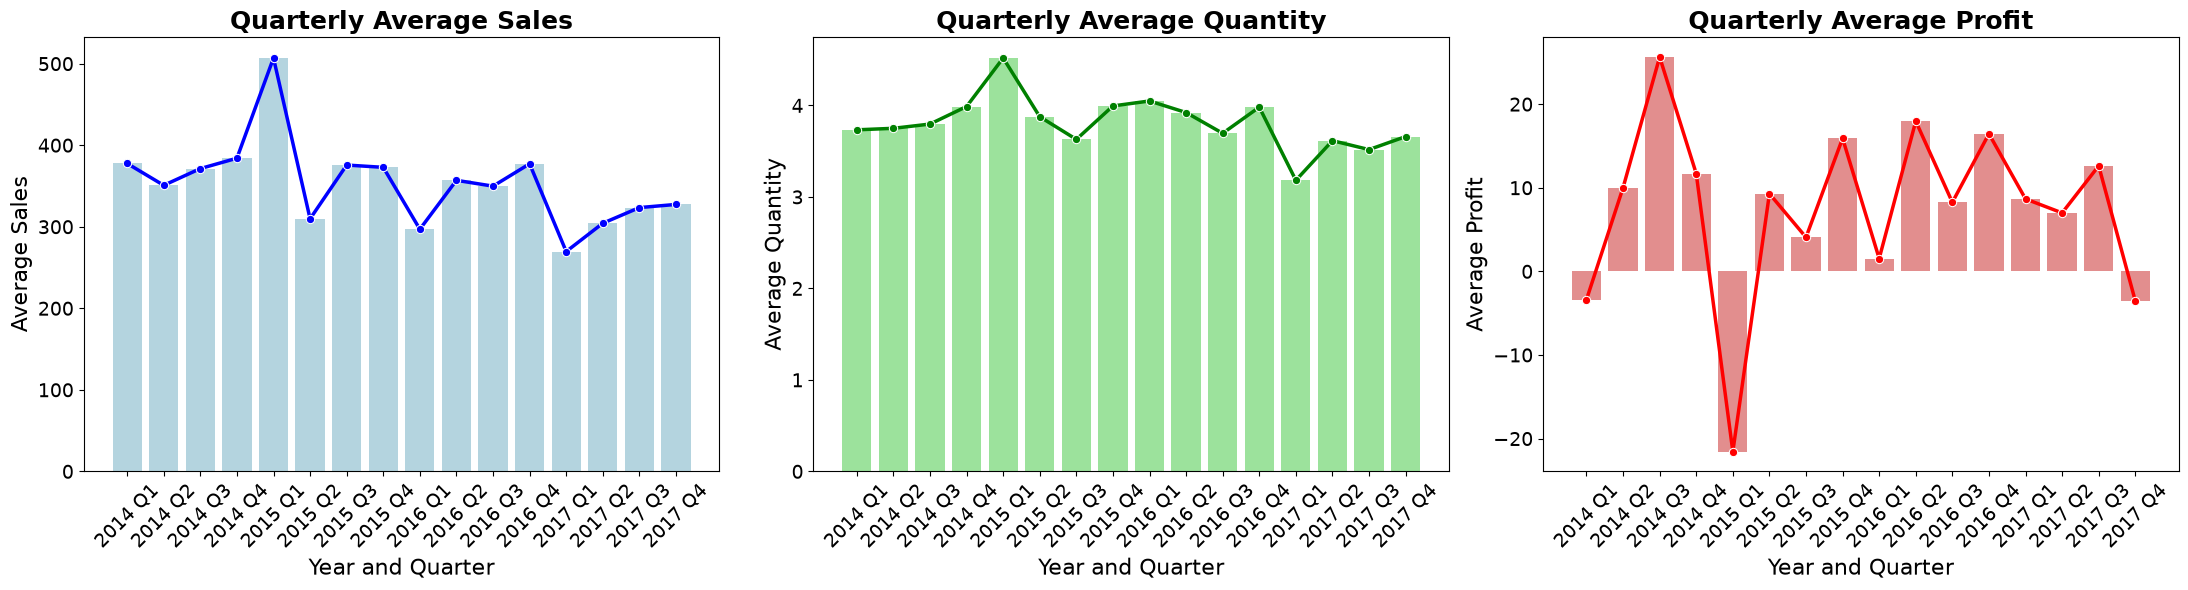

In [98]:
# Visualise with bar charts
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

metrics = ['Sales', 'Quantity', 'Profit']
titles = [
    'Quarterly Average Sales',
    'Quarterly Average Quantity',
    'Quarterly Average Profit'
]

title_style = {
    'fontsize': 18,
    'fontweight': 'bold',
    'color': 'black'
}

bar_colors = ['lightblue', 'lightgreen', 'lightcoral']
line_colors = ['blue', 'green', 'red']

for ax, metric, title, color, line_color in zip(
    axes,
    metrics,
    titles,
    bar_colors,
    line_colors
):

    sns.barplot(
        data=quarterly_avg_by_yr,
        x='Year_Quarter',
        y=metric,
        color=color,
        ax=ax
    )

    sns.lineplot(
        data=quarterly_avg_by_yr,
        x='Year_Quarter',
        y=metric,
        color=line_color,
        marker='o',
        linewidth=2.5,
        ax=ax
    )

    ax.set_title(title, **title_style)
    ax.set_xlabel('Year and Quarter', fontsize=16)
    ax.set_ylabel(f'Average {metric}', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Identify correlated variables

In [5]:
#

## 5. Summary